In [8]:
import torch

# 创建不同维度的张量
scalar = torch.tensor(5.0)          # 0维：标量
vector = torch.tensor([1, 2, 3])     # 1维：向量
matrix = torch.tensor([[1, 2], [3, 4]])  # 2维：矩阵
tensor_3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])  # 3维张量

print("标量:", scalar, "形状:", scalar.shape)
print("向量:", vector, "形状:", vector.shape)
print("矩阵:", matrix, "形状:", matrix.shape)
print("3维张量形状:", tensor_3d.shape)

标量: tensor(5.) 形状: torch.Size([])
向量: tensor([1, 2, 3]) 形状: torch.Size([3])
矩阵: tensor([[1, 2],
        [3, 4]]) 形状: torch.Size([2, 2])
3维张量形状: torch.Size([2, 2, 2])


In [16]:
# 创建两个矩阵
A = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
B = torch.tensor([[5, 6], [7, 8]], dtype=torch.float32)

print("矩阵A:")
print(A)
print("矩阵B:")
print(B)

# 矩阵乘法
C = torch.matmul(A, B)  # 或者使用 A @ B
print("矩阵乘法结果 A × B:")
print(C)

# 逐元素乘法（不是矩阵乘法）
D = A * B
print("逐元素乘法 A * B:")
print(D)

矩阵A:
tensor([[1., 2.],
        [3., 4.]])
矩阵B:
tensor([[5., 6.],
        [7., 8.]])
矩阵乘法结果 A × B:
tensor([[19., 22.],
        [43., 50.]])
逐元素乘法 A * B:
tensor([[ 5., 12.],
        [21., 32.]])


In [17]:
A_T = A.T
print("A的转置:")
print(A_T)

A的转置:
tensor([[1., 3.],
        [2., 4.]])


In [ ]:
import torch.nn.functional as F

# 创建一些分数（比如注意力分数）
scores = torch.tensor([2.0, 1.0, 0.1], dtype=torch.float32)
print("原始分数:", scores)

# 手动实现softmax
def manual_softmax(x):
    exp_x = torch.exp(x - torch.max(x))  # 减去最大值防止数值溢出 这是一个softmax的体
    return exp_x / torch.sum(exp_x)

# 使用PyTorch的softmax
manual_result = manual_softmax(scores)
pytorch_result = F.softmax(scores, dim=0)

print("手动softmax结果:", manual_result)
print("PyTorch softmax结果:", pytorch_result)
print("总和（应为1）:", torch.sum(manual_result))

# 理解softmax的特性
print("\n--- Softmax特性演示 ---")
# 当分数差异很大时
large_diff = torch.tensor([10.0, 1.0, 0.1])
print("大差异分数:", large_diff)
print("softmax结果:", F.softmax(large_diff, dim=0))

# 当分数很接近时
small_diff = torch.tensor([1.1, 1.0, 0.9])
print("小差异分数:", small_diff)
print("softmax结果:", F.softmax(small_diff, dim=0))

原始分数: tensor([2.0000, 1.0000, 0.1000])
手动softmax结果: tensor([0.6590, 0.2424, 0.0986])
PyTorch softmax结果: tensor([0.6590, 0.2424, 0.0986])
总和（应为1）: tensor(1.0000)

--- Softmax特性演示 ---
大差异分数: tensor([10.0000,  1.0000,  0.1000])
softmax结果: tensor([9.9983e-01, 1.2339e-04, 5.0166e-05])
小差异分数: tensor([1.1000, 1.0000, 0.9000])
softmax结果: tensor([0.3672, 0.3322, 0.3006])


In [19]:
# 广播示例
matrix = torch.tensor([[1, 2, 3], 
                       [4, 5, 6]], dtype=torch.float32)
vector = torch.tensor([10, 20, 30], dtype=torch.float32)

# 广播：vector会被复制成与matrix相同的形状
result = matrix + vector
print("矩阵:")
print(matrix)
print("向量:")
print(vector)
print("广播加法结果:")
print(result)

矩阵:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
向量:
tensor([10., 20., 30.])
广播加法结果:
tensor([[11., 22., 33.],
        [14., 25., 36.]])


In [25]:
A = torch.randn(3,4)
B = torch.randn(3,1)
Q = torch.randn(4,3)

C = A @ Q 
D = A + B
print(f"这是A：{A}")
print(f"这是B：{B}")
print(f"这是叉乘：{C}")
print(f"这是广播：{D}")

这是A：tensor([[ 0.5060,  0.1889,  0.2613,  1.5651],
        [ 1.7293,  0.3468, -1.4735,  0.5285],
        [ 0.6777, -0.7566,  1.3330,  1.0652]])
这是B：tensor([[0.3524],
        [1.5520],
        [1.6821]])
这是叉乘：tensor([[-3.7093,  0.6775, -2.1081],
        [-1.6171,  3.0500, -0.5617],
        [-2.5005, -1.2310, -0.0386]])
这是广播：tensor([[0.8585, 0.5414, 0.6137, 1.9175],
        [3.2813, 1.8989, 0.0786, 2.0806],
        [2.3597, 0.9254, 3.0151, 2.7473]])


In [29]:
batch_scores = torch.tensor([[1.0, 2.0, 3.0],
                             [0.5, 1.5, 2.5]], dtype=torch.float32)
pytorch_result = F.softmax(batch_scores, dim=-1)
print(f"{pytorch_result}")

tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])


In [28]:
# 观察以下操作的形状变化
tensor_3d = torch.randn(2, 3, 4)  # 2个3x4矩阵
print("原始形状:", tensor_3d.shape)
# 尝试不同的转置和重塑操作

原始形状: torch.Size([2, 3, 4])


In [30]:
import torch
import torch.nn as nn
import math

# 我们先从最简单的单头注意力开始理解
class SimpleSelfAttention:
    def __init__(self, d_model, d_k):
        self.d_k = d_k
        # 初始化权重矩阵（在实际中这些是学习得到的）
        self.W_q = torch.randn(d_model, d_k) * 0.02
        self.W_k = torch.randn(d_model, d_k) * 0.02
        self.W_v = torch.randn(d_model, d_k) * 0.02
        
    def forward(self, x):
        """
        x: 输入序列 [seq_len, d_model]
        """
        # 计算Q, K, V
        Q = torch.matmul(x, self.W_q)  # [seq_len, d_k]
        K = torch.matmul(x, self.W_k)  # [seq_len, d_k]
        V = torch.matmul(x, self.W_v)  # [seq_len, d_k]
        
        # 计算注意力分数: Q × K^T
        scores = torch.matmul(Q, K.T)  # [seq_len, seq_len]
        
        # 缩放：防止softmax的梯度消失问题
        scores = scores / math.sqrt(self.d_k)
        
        # 应用softmax得到注意力权重
        attention_weights = torch.softmax(scores, dim=-1)  # [seq_len, seq_len]
        
        # 加权求和
        output = torch.matmul(attention_weights, V)  # [seq_len, d_k]
        
        return output, attention_weights

In [32]:
tensor = torch.randn(2, 3, 6)  # 形状: [batch_size, seq_len, d_k]
print(tensor.size(-1))  # 输出: 4（最后一个维度的大小）

6


In [33]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    计算缩放点积注意力
    
    参数:
    q: 查询张量 [..., seq_len_q, d_k]
    k: 键张量 [..., seq_len_k, d_k]  
    v: 值张量 [..., seq_len_v, d_v]
    mask: 掩码张量（可选）
    
    返回:
    output: 加权和 [..., seq_len_q, d_v]
    attention_weights: 注意力权重 [..., seq_len_q, seq_len_k]
    """
    
    # 1. 计算 Q × K^T
    matmul_qk = torch.matmul(q, k.transpose(-2, -1))  # [..., seq_len_q, seq_len_k]
    
    # 2. 缩放
    d_k = q.size(-1)
    scaled_attention_logits = matmul_qk / math.sqrt(d_k)
    
    # 3. 应用掩码（如果有）
    if mask is not None:
        # 将掩码为0的位置替换为极小的负数，这样softmax后接近0
        scaled_attention_logits += (mask * -1e9)
    
    # 4. 应用softmax得到注意力权重
    attention_weights = torch.softmax(scaled_attention_logits, dim=-1)  # [..., seq_len_q, seq_len_k]
    
    # 5. 加权求和
    output = torch.matmul(attention_weights, v)  # [..., seq_len_q, d_v]
    
    return output, attention_weights
# 测试数据：一个包含3个词的小序列，每个词用4维向量表示
seq_len = 3
d_model = 4
d_k = 2

# 创建输入序列
x = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                  [2.0, 3.0, 4.0, 5.0], 
                  [3.0, 4.0, 5.0, 6.0]], dtype=torch.float32)

print("输入序列:")
print(x)
print("形状:", x.shape)
print()

# 创建简单的线性变换权重
W_q = torch.tensor([[0.1, 0.2],
                    [0.3, 0.4],
                    [0.5, 0.6],
                    [0.7, 0.8]], dtype=torch.float32)

W_k = torch.tensor([[0.2, 0.1],
                    [0.4, 0.3],
                    [0.6, 0.5], 
                    [0.8, 0.7]], dtype=torch.float32)

W_v = torch.tensor([[0.3, 0.4],
                    [0.5, 0.6],
                    [0.7, 0.8],
                    [0.9, 1.0]], dtype=torch.float32)

# 计算Q, K, V
Q = torch.matmul(x, W_q)  # [3, 2]
K = torch.matmul(x, W_k)  # [3, 2]  
V = torch.matmul(x, W_v)  # [3, 2]

print("查询Q:")
print(Q)
print("键K:")
print(K) 
print("值V:")
print(V)
print()

# 测试我们的缩放点积注意力函数
output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("注意力权重:")
print(attention_weights)
print("每行和（应为1）:", torch.sum(attention_weights, dim=1))
print()
print("输出:")
print(output)
print("输出形状:", output.shape)

输入序列:
tensor([[1., 2., 3., 4.],
        [2., 3., 4., 5.],
        [3., 4., 5., 6.]])
形状: torch.Size([3, 4])

查询Q:
tensor([[ 5.0000,  6.0000],
        [ 6.6000,  8.0000],
        [ 8.2000, 10.0000]])
键K:
tensor([[ 6.0000,  5.0000],
        [ 8.0000,  6.6000],
        [10.0000,  8.2000]])
值V:
tensor([[ 7.0000,  8.0000],
        [ 9.4000, 10.8000],
        [11.8000, 13.6000]])

注意力权重:
tensor([[9.1616e-13, 9.5717e-07, 1.0000e+00],
        [1.0744e-16, 1.0366e-08, 1.0000e+00],
        [1.2601e-20, 1.1225e-10, 1.0000e+00]])
每行和（应为1）: tensor([1., 1., 1.])

输出:
tensor([[11.8000, 13.6000],
        [11.8000, 13.6000],
        [11.8000, 13.6000]])
输出形状: torch.Size([3, 2])


/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 38190 (\N{CJK UNIFIED IDEOGRAPH-952E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 35810 (\N{CJK UNIFIED IDEOGRAPH-8BE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21360/998036177.py:35: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8

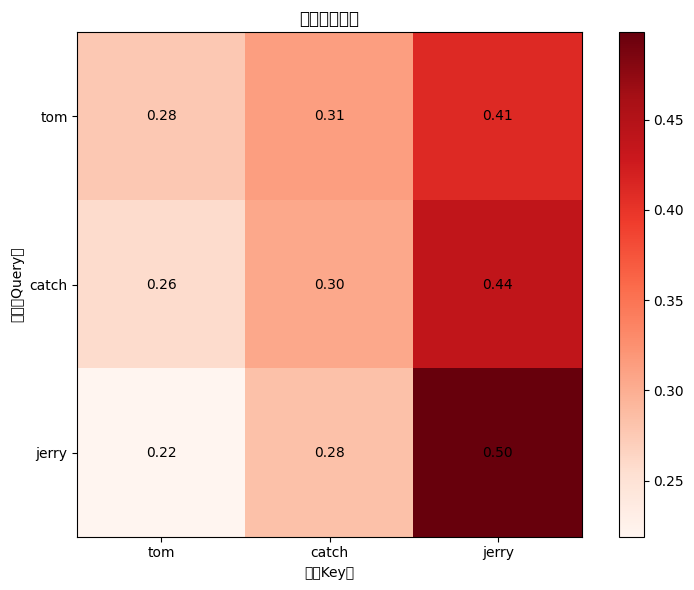

注意力权重矩阵解释:
每一行表示一个查询词（行标签）对所有键词（列标签）的注意力权重
例如，第一行表示'猫'对'猫'、'追'、'老鼠'的注意力分布


In [35]:
import matplotlib.pyplot as plt

# 创建一个更有意义的例子
words = ["tom", "catch", "jerry"]
# 简单的词向量（实际中会使用预训练的词向量）
word_embeddings = torch.tensor([
    [1.0, 0.5, 0.2, 0.1],  # 猫
    [0.1, 1.0, 0.3, 0.2],  # 追  
    [0.2, 0.3, 1.0, 0.5]   # 老鼠
], dtype=torch.float32)

# 使用相同的权重计算注意力
Q = torch.matmul(word_embeddings, W_q)
K = torch.matmul(word_embeddings, W_k) 
V = torch.matmul(word_embeddings, W_v)

output, attention_weights = scaled_dot_product_attention(Q, K, V)

# 可视化注意力权重
plt.figure(figsize=(8, 6))
plt.imshow(attention_weights.detach().numpy(), cmap='Reds')
plt.colorbar()
plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)
plt.title("自注意力权重")
plt.xlabel("键（Key）")
plt.ylabel("查询（Query）")

# 在热力图上显示数值
for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{attention_weights[i, j]:.2f}", 
                ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

print("注意力权重矩阵解释:")
print("每一行表示一个查询词（行标签）对所有键词（列标签）的注意力权重")
print("例如，第一行表示'猫'对'猫'、'追'、'老鼠'的注意力分布")

In [ ]:
# 给定以下简化的Q, K, V
Q_simple = torch.tensor([[1.0, 0.5]], dtype=torch.float32)  # [1, 2]
K_simple = torch.tensor([[0.5, 1.0], [1.0, 0.5]], dtype=torch.float32)  # [2, 2]
V_simple = torch.tensor([[0.1, 0.2], [0.3, 0.4]], dtype=torch.float32)  # [2, 2]

# 请手动计算注意力权重和输出，然后与函数结果对比

/home/lee/miniconda3/envs/lerobot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                                    text  label label_name
0                                i didnt feel humiliated      0    sadness
1      i can go from feeling so hopeless to so damned...      0    sadness
2       im grabbing a minute to post i feel greedy wrong      3      anger
3      i am ever feeling nostalgic about the fireplac...      2       love
4                                   i am feeling grouchy      3      anger
...                                                  ...    ...        ...
15995  i just had a very brief time in the beanbag an...      0    sadness
15996  i am now turning and i feel pathetic that i am...      0    sadness
15997                     i feel strong and good overall      1        joy
15998  i feel like this was such a rude comment and i...      3      anger
15999  i know a lot but i feel so stupid because i ca...      0    sadness

[16000 rows x 3 columns]


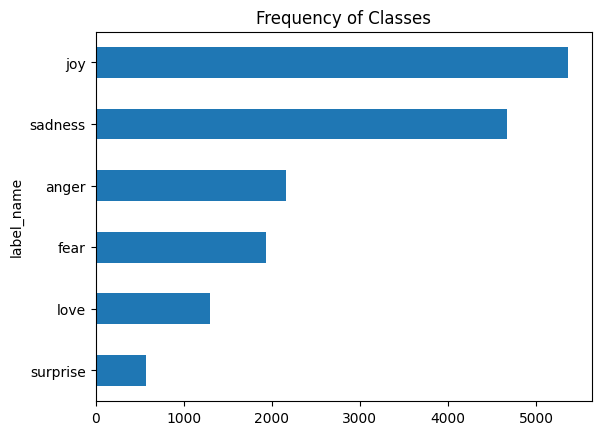

In [1]:
#以下是transfomer上

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

ds = load_dataset("dair-ai/emotion", "split")
ds.set_format(type='pandas')

df = ds ['train'][:]
df.head(5)

def label_int2str(row): #int2str是huggingface提供的一个将label数字转换成文字的方法
    return ds['train'].features['label'].int2str(row)
df ['label_name'] = df ['label'].apply(label_int2str)#使用apply应用修改

print(df)

df ['label_name'].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [9]:
from datasets import load_dataset
import pandas as pd

# 加载数据集
ds = load_dataset("dair-ai/emotion")

# 获取前10个样本
train_data = ds['train'].select(range(10))

# 转换为pandas DataFrame
df = pd.DataFrame({
    'text': train_data['text'],
    'label': train_data['label']
})

print("数据集前10行:")
print(df)
print("\n数据类型:")
print(f"text列类型: {type(df['text'])}")
print(f"第一条记录类型: {type(df['text'].iloc[0])}")

# 分词处理
print("\n分词处理:")

# 对DataFrame中的文本进行分词
df['tokens'] = df['text'].apply(lambda x: x.split())

# 或者使用str.split()方法
# df['tokens'] = df['text'].str.split()

print("\n结果:")
for i, row in df.iterrows():
    print(f"样本 {i+1}:")
    print(f"  文本: {row['text']}")
    print(f"  标签: {row['label']}")
    print(f"  分词: {row['tokens']}")
    print(f"  token数量: {len(row['tokens'])}\n")

数据集前10行:
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3
5  ive been feeling a little burdened lately wasn...      0
6  ive been taking or milligrams or times recomme...      5
7  i feel as confused about life as a teenager or...      4
8  i have been with petronas for years i feel tha...      1
9                                i feel romantic too      2

数据类型:
text列类型: <class 'pandas.core.series.Series'>
第一条记录类型: <class 'str'>

分词处理:

结果:
样本 1:
  文本: i didnt feel humiliated
  标签: 0
  分词: ['i', 'didnt', 'feel', 'humiliated']
  token数量: 4

样本 2:
  文本: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  标签: 0
  分词: ['i', 'c

In [2]:
#现在演示WordPiece的使用，这是一个很常用的子词词元化算法，BERT和DistilBERT词元分析器使用的正是WordPiece
#现在加载DistilBERT的词元
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
#AutoTokenizer类的任务是根据checkpoint的名称自动检索模型的配置、预训练权重或词表
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
#也可以手动加载这个类

from transformers import DistilBertTokenizer

model_ckpt = "distilbert-base-uncased"
#AutoTokenizer类的任务是根据checkpoint的名称自动检索模型的配置、预训练权重或词表
tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)


In [8]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
#AutoTokenizer类的任务是根据checkpoint的名称自动检索模型的配置、预训练权重或词表
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
text = "哈吉米哟南北绿豆！"
encode_text = tokenizer(text)
print(encode_text)

{'input_ids': [101, 100, 1793, 100, 100, 1785, 1781, 100, 100, 1986, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [24]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
#AutoTokenizer类的任务是根据checkpoint的名称自动检索模型的配置、预训练权重或词表
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
text = "ha ji mi yo na be lv do！"
encoded_text = tokenizer(text)
print(encoded_text)
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)
string = tokenizer.convert_tokens_to_string(tokens)
print(string)
print(tokenizer.vocab_size)
print(tokenizer.model_max_length)
print(tokenizer.model_input_names)

{'input_ids': [101, 5292, 10147, 2771, 10930, 6583, 2022, 1048, 2615, 2079, 1986, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
['[CLS]', 'ha', 'ji', 'mi', 'yo', 'na', 'be', 'l', '##v', 'do', '！', '[SEP]']
[CLS] ha ji mi yo na be lv do ！ [SEP]
30522
512
['input_ids', 'attention_mask']


In [26]:
#接下来是对整个数据集进行词元化
from transformers import AutoTokenizer
from datasets import load_dataset
import pandas as pd

# 加载数据集
ds = load_dataset("dair-ai/emotion")

def tokenize(batch):
    return tokenizer(batch["text"],padding=True,truncation=True)

print(tokenize(ds["train"][:2]))

emotions_encoded = ds.map(tokenize,batched=True,batch_size=None)
print(emotions_encoded["train"].column_names)


{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


Map: 100%|██████████| 2000/2000 [00:00<00:00, 38460.45 examples/s]

['text', 'label', 'input_ids', 'attention_mask']
